# Heston Model Calibration on Real Market Data 

Fast vectorized Heston calibration with calls, puts, implied volatility, RMSE, and IV smiles.


# Fast Heston Calibration with Calls, Puts, Implied Volatility, RMSE, and IV Smiles

This notebook calibrates the Heston stochastic volatility model to option quotes for a **single quote date**. It supports both calls and puts, computes model prices, converts model and market prices into Black implied volatilities, evaluates in-sample and holdout errors, and visualizes implied-volatility smiles and surfaces.


### 1. Data Preparation

The option data and filtered to one ticker **SPX**:

Each row represents an option quote with fields such as *quote date, expiration date, option type, strike, forward price, time to maturity, bid price, ask price, mid price, and market implied volatility*.

The mid price is used as the observed market price:

$$
P_{\text{mid}} = \frac{P_{\text{bid}} + P_{\text{ask}}}{2}
$$

A random train-holdout split is created within each ticker, quote date, and expiration date group. This preserves enough visible quotes per expiration while setting aside a portion of quotes for out-of-sample testing.


### 2. Train and Holdout Split

For each group defined by ticker, quote date, a fraction of quotes is randomly selected as holdout data.

The number of holdout options in each group is constrained so that at least MIN_VISIBLE options remain visible for calibration.

The visible data is used for model fitting. The holdout data is used later to evaluate out-of-sample pricing and implied-volatility errors.

### 3. Risk-Free Rate Curve

The notebook fits a Nelson-Siegel-Svensson yield curve using Treasury par yields.

The maturity vector is:

$$
T =
\left[
\frac{1}{12},
\frac{2}{12},
\frac{3}{12},
\frac{6}{12},
1,
2,
3,
5,
7,
10,
20,
30
\right]
$$

The observed Treasury yields are converted from percentages to decimals and used to fit the curve.

For each option, the risk-free rate is evaluated at the option’s time to maturity:

$$
r_i = r(\tau_i)
$$

where $\tau_i$ is the time to maturity of option $i$ in years.

### 4. Heston Stochastic Volatility Model

The Heston model assumes that the underlying asset price follows:

$$
dS_t = rS_t,dt + \sqrt{v_t}S_t,dW_t^S
$$

The variance process follows:

$$
dv_t = \kappa(\theta - v_t),dt + \sigma\sqrt{v_t},dW_t^v
$$

The two Brownian motions are correlated:

$$
dW_t^S dW_t^v = \rho,dt
$$

The model parameters are:

Parameter	Meaning
$v_0$	Initial variance
$\kappa$	Speed of mean reversion
$\theta$	Long-run variance
$\sigma$	Volatility of variance
$\rho$	Correlation between asset and variance shocks
$\lambda$	Volatility risk premium

In this implementation, the volatility risk premium is fixed at:

$$
\lambda = 0
$$

The calibrated parameter vector is therefore:

$$
\Theta = (v_0, \kappa, \theta, \sigma, \rho)
$$

### 5. Heston Characteristic Function

The code evaluates the Heston characteristic function in vectorized form over all integration nodes and all option contracts.

The following quantities are used:

$$
a = \kappa\theta
$$

$$
b = \kappa + \lambda
$$

$$
d =
\sqrt{
(\rho\sigma i\phi - b)^2
+
\sigma^2(i\phi + \phi^2)
}
$$

$$
g =
\frac{
b - \rho\sigma i\phi + d
}{
b - \rho\sigma i\phi - d
}
$$

The characteristic function is then evaluated for the transformed integration variable $\phi$ and maturity $\tau$.




### 6. Heston Call Pricing Formula

The Heston call price is computed using Fourier inversion and numerical integration.

The call price is:

$$
C =
\frac{S_0 - Ke^{-rT}}{2}
+
\frac{1}{\pi}
\int_0^\infty
\Re
\left[
\frac{
e^{rT}\varphi(\phi - i) - K\varphi(\phi)
}{
i\phi K^{i\phi}
}
\right]
d\phi
$$

where:

* $S_0$ is the spot or spot proxy,
* $K$ is the strike,
* $T$ is time to maturity,
* $r$ is the risk-free rate,
* $\varphi(\cdot)$ is the Heston characteristic function,
* $\Re[\cdot]$ denotes the real part.

The integral is approximated using Gauss-Legendre quadrature over the finite interval:

$$
[0, U_{\max}]
$$

The number of integration nodes is controlled by N_INT.

### 7. Put Pricing Using Put-Call Parity

The implemented Heston formula directly computes call prices. Put prices are obtained from forward put-call parity.

The parity relationship is:

$$
C - P = e^{-rT}(F - K)
$$

Solving for the put price gives:

$$
P = C - e^{-rT}(F - K)
$$

where:

* $C$ is the Heston call price,
* $P$ is the Heston put price,
* $F$ is the forward price,
* $K$ is the strike,
* $T$ is time to maturity.

This step is necessary because market put rows must be compared against model put prices, not model call prices.



### 8. Black-Scholes Option Pricing

Black-Scholes is used to convert option prices into implied volatilities.

Define:

$$
d_1 =
\frac{
\ln(F/K) + \frac{1}{2}\sigma^2 T
}{
\sigma\sqrt{T}
}
$$

$$
d_2 = d_1 - \sigma\sqrt{T}
$$

The discount factor is:

$$
DF = e^{-rT}
$$

The Black-Scholes call price is:

$$
C_{\text{Black}} = 

DF
\left[
F N(d_1) - K N(d_2)
\right]
$$

The Black-Scholes put price is:

$$
P_{\text{Black}} = 

DF
\left[
K N(-d_2) - F N(-d_1)
\right]
$$

where $N(\cdot)$ is the standard normal cumulative distribution function.


### 9. Implied Volatility Inversion

The implied volatility is the volatility value that makes the Black-76 price equal to the observed option price.

For each option, the code solves:

$$
V_{\text{Black}}(F, K, T, r, \sigma_{\text{impl}}, \text{type})

V_{\text{target}}
$$

Equivalently, it finds the root of:

$$
f(\sigma)

V_{\text{Black}}(\sigma) - V_{\text{target}}
$$

The root is found using Brent’s method over the interval:

$$
\sigma \in [10^{-6}, 5.0]
$$

The same inversion procedure is used for:

* market implied volatility from market mid price,
* Heston implied volatility from Heston model price.


### 10. Calibration Dataset

The calibration data is filtered to remove illiquid, extreme, or invalid quotes.

The time-to-maturity filter is:

$$
\tau_{\min} < \tau < \tau_{\max}
$$

The mid-price filter is:

$$
P_{\text{mid}} > P_{\min}
$$

The moneyness filter is:

$$
m_{\min} < \frac{K}{F} < m_{\max}
$$

Moneyness is defined as:

$$
m = \frac{K}{F}
$$

The notebook uses out-of-the-money options by default.

For puts:

$$
K < F
$$

For calls:

$$
K \ge F
$$

This gives a standard OTM volatility surface construction:

* OTM puts below the forward,
* OTM calls above the forward.

This avoids fitting duplicate call-put information at the same strike and reduces sensitivity to put-call parity noise.

### 11. Bid-Ask Spread Weighting

The bid-ask spread is computed as:

$$
\text{spread}_i = \text{ask}_i - \text{bid}_i
$$

The spread is clipped from below:

$$
\text{spread}_i = \max(\text{spread}_i, 0.05)
$$

The calibration residual for option $i$ is:

$$
\epsilon_i =
\frac{
V_i^{\text{Heston}} - V_i^{\text{market}}
}{
\text{spread}_i
}
$$

This weighting gives less influence to options with wide bid-ask spreads and more influence to tighter, more liquid quotes.

### 12. Calibration Objective

The optimizer solves a bounded nonlinear least-squares problem.

The objective is:

$$
\min_{\Theta}
\sum_{i=1}^{N}
\rho_{\text{loss}}
\left(
\epsilon_i^2
\right)
$$

where:

$$
\Theta = (v_0, \kappa, \theta, \sigma, \rho)
$$

and:

$$
\lambda = 0
$$

The residual is:

$$
\epsilon_i =
\frac{
V_i^{\text{Heston}}(\Theta) - V_i^{\text{market}}
}{
\text{spread}_i
}
$$

The notebook uses SciPy’s least_squares optimizer with:

* trust-region reflective method,
* parameter bounds,
* robust soft_l1 loss,
* maximum number of function evaluations controlled by max_nfev.


### 13. Parameter Bounds

The calibrated parameters are constrained as follows:

Parameter	Lower Bound	Upper Bound
$v_0$	$10^{-4}$	$0.5$
$\kappa$	$10^{-3}$	$10.0$
$\theta$	$10^{-4}$	$0.5$
$\sigma$	$10^{-3}$	$3.0$
$\rho$	$-0.999$	$0.999$

These bounds prevent numerically unstable or economically unreasonable parameter values during optimization.

### 14. Feller Condition Penalty

The Heston variance process is strictly positive when the Feller condition holds:

$$
2\kappa\theta \ge \sigma^2
$$

The code does not impose this condition as a hard constraint. Instead, it adds a soft penalty when the condition is violated.

The violation is:

$$
\text{violation}

\max(0, \sigma^2 - 2\kappa\theta)
$$

The penalty residual is:

$$
\epsilon_{\text{Feller}}

10 \times \text{violation}
$$

This discourages parameter sets that strongly violate the Feller condition while still allowing the optimizer some flexibility.

### 15. In-Sample Price and Implied-Volatility Diagnostics

After calibration, the model computes Heston prices for the calibration options.

The price error is:

$$
e_i^P =
V_i^{\text{Heston}} - V_i^{\text{market}}
$$

The relative price error is:

$$
e_i^{\text{rel}} =
\frac{
V_i^{\text{Heston}} - V_i^{\text{market}}
}{
\max(V_i^{\text{market}}, 10^{-8})
}
$$

The implied-volatility error is:

$$
e_i^{IV} =
IV_i^{\text{Heston}} - IV_i^{\text{market}}
$$

The price RMSE is:

$$
\text{Price RMSE}

\sqrt{
\frac{1}{N}
\sum_{i=1}^{N}
(e_i^P)^2
}
$$

The price MAE is:

$$
\text{Price MAE}

\frac{1}{N}
\sum_{i=1}^{N}
|e_i^P|
$$

The price MAPE is:

$$
\text{Price MAPE}

\frac{1}{N}
\sum_{i=1}^{N}
|e_i^{\text{rel}}|
$$

The implied-volatility RMSE is:

$$
\text{IV RMSE}

\sqrt{
\frac{1}{N}
\sum_{i=1}^{N}
(e_i^{IV})^2
}
$$

The implied-volatility MAE is:

$$
\text{IV MAE}

\frac{1}{N}
\sum_{i=1}^{N}
|e_i^{IV}|
$$

The implied-volatility errors are also reported in volatility points:

$$
\text{IV RMSE vol points}

100 \times \text{IV RMSE}
$$

$$
\text{IV MAE vol points}

100 \times \text{IV MAE}
$$

### 16. Diagnostic Plots

The notebook produces several visual diagnostics.

Market Price vs Heston Price

This scatter plot compares market mid prices against Heston model prices.

A good fit should place points close to the 45-degree line:

$$
V^{\text{Heston}} = V^{\text{market}}
$$

Market IV vs Heston IV

This scatter plot compares market implied volatility against Heston implied volatility.

A good fit should satisfy:

$$
IV^{\text{Heston}} \approx IV^{\text{market}}
$$

3D Implied Volatility Surface

The notebook plots both market and Heston implied volatilities as functions of maturity and strike:

$$
IV = IV(\tau, K)
$$

Interpolated Heston IV Surface

The Heston implied volatility points are interpolated onto a maturity-strike grid using linear interpolation.

The interpolated surface is:

$$
IV_{\text{Heston}} = f(\tau, K)
$$

Volatility Smiles by Strike

For selected maturity buckets, the notebook plots implied volatility as a function of strike:

$$
IV = IV(K)
$$

Volatility Smiles by Moneyness

The notebook also plots implied volatility as a function of moneyness:

$$
IV = IV\left(\frac{K}{F}\right)
$$

This makes smiles easier to compare across maturities.


### 17. Holdout Evaluation

After calibration, the fitted Heston parameters are applied to the holdout set.

The same filtering logic is applied to the holdout data:

$$
\tau_{\min} < \tau < \tau_{\max}
$$

$$
P_{\text{mid}} > P_{\min}
$$

$$
m_{\min} < \frac{K}{F} < m_{\max}
$$

The model then computes:

* Heston holdout prices,
* market implied volatilities,
* Heston implied volatilities,
* price errors,
* relative price errors,
* implied-volatility errors,
* RMSE,
* MAE,
* MAPE.

This provides an out-of-sample check of whether the calibrated model generalizes to quotes not used during fitting.

### 18. Why Calls and Puts Need Separate Handling

The Heston pricing function computes call prices directly.

If put rows are included in the calibration data, those rows must be assigned model put prices. The notebook does this using put-call parity:

$$
P = C - e^{-rT}(F - K)
$$

Without this adjustment, market put prices would be incorrectly compared against model call prices, causing large calibration errors.


### 19. Why OTM Options Are Used

The default calibration mode is:

CALIBRATION_MODE = "otm_only"

This keeps:

* puts with $K < F$,
* calls with $K \ge F$.

This is a common approach for building volatility surfaces because OTM options are usually more liquid and avoid redundant call-put quotes at the same strike.

It also reduces the impact of put-call parity violations caused by:

* bid-ask noise,
* stale quotes,
* discrete dividends,
* asynchronous call and put prices,
* data-cleaning errors.

### 20. Speed and Accuracy Tradeoff

For faster exploratory runs, use:

N_INT = 128
max_nfev = 200

For a more accurate final calibration, use:

N_INT = 512
max_nfev = 1000

Larger N_INT improves numerical integration accuracy but increases runtime.

### 21. Summary of Workflow

The notebook performs the following steps:

1. Load SPX option quote data.
2. Split quotes into visible calibration data and holdout data.
3. Fit a Nelson-Siegel-Svensson risk-free rate curve.
4. Select one quote date.
5. Filter the calibration data by maturity, price, moneyness, and option type.
6. Keep OTM puts and OTM calls.
7. Price calls using the Heston characteristic-function formula.
8. Price puts using put-call parity.
9. Calibrate Heston parameters using spread-weighted residuals.
10. Add a soft Feller-condition penalty.
11. Convert market and model prices to Black-76 implied volatilities.
12. Compute price and implied-volatility errors.
13. Report RMSE, MAE, and MAPE diagnostics.
14. Plot price fits, IV fits, volatility surfaces, and volatility smiles.
15. Evaluate the calibrated model on holdout quotes.

The final calibrated model is defined by:

$$
(v_0, \kappa, \theta, \sigma, \rho)
$$

with:

$$
\lambda = 0
$$

#### Import packages

In [2]:
# ============================================================
# 0. Imports
# ============================================================

import numpy as np
import pandas as pd

from pathlib import Path
from scipy.optimize import least_squares, brentq
from scipy.stats import norm
from scipy.interpolate import griddata
from numpy.polynomial.legendre import leggauss

import matplotlib.pyplot as plt
import plotly.graph_objects as go

from nelson_siegel_svensson.calibrate import calibrate_nss_ols

#### Configuration of params

In [3]:
# ============================================================
# 1. Configuration
# ============================================================

DATA_PATH = Path('/Users/uran/Desktop/ErdosBootcamp/Project_Quant_Finance/Quant-Finance-project/Processed_data/surface_all.parquet')

TICKER = "SPX"
QUOTE_DATE = "2023-01-04"

CALIBRATION_MODE = "otm_only"

HOLDOUT_FRAC = 0.20
MIN_VISIBLE = 6
SPLIT_SEED = 0

# Heston integration settings
UMAX = 200.0
N_INT = 64        # 64 already matches a reference pricer to ~1e-6; raise to 128 for a final run

# Calibration filters
MIN_TAU = 7 / 365
MAX_TAU = 1.0
MIN_MID_PRICE = 0.05
MONEYNESS_LOW = 0.60
MONEYNESS_HIGH = 1.70

# Implied-volatility inversion bounds
IV_LOW = 1e-6
IV_HIGH = 5.0

#### Prepare data

In [4]:
# ============================================================
# 2. Load data
# ============================================================

df = pd.read_parquet(DATA_PATH)
df = df[df["ticker"] == TICKER].copy().reset_index(drop=True)
df["type"] = df["type"].astype(str).str.lower()
print(f"{TICKER}: {len(df):,} quotes over {df['quote_date'].nunique()} quote dates")

SPX: 1,462,299 quotes over 249 quote dates


In [5]:
# ============================================================
# 3. Train / holdout split
# ============================================================

def make_holdout(frame, frac=0.2, min_vis=6, seed=0):
    """
    Randomly select holdout quotes inside each
    ticker / quote_date / expire_date group, while keeping at least
    min_vis visible quotes per group.
    """
    rng = np.random.default_rng(seed)
    hold = pd.Series(False, index=frame.index)

    for _, sl in frame.groupby(["ticker", "quote_date", "expire_date"]):
        n = len(sl)
        n_hold = min(int(round(frac * n)), max(0, n - min_vis))

        if n_hold > 0:
            idx = rng.choice(sl.index.values, size=n_hold, replace=False)
            hold.loc[idx] = True

    return hold


df["is_holdout"] = make_holdout(
    df,
    frac=HOLDOUT_FRAC,
    min_vis=MIN_VISIBLE,
    seed=SPLIT_SEED,
)

# Day-level feature using visible data only
lvl = (
    df.loc[~df["is_holdout"]]
      .groupby(["ticker", "quote_date"])["iv"]
      .median()
      .rename("day_level")
      .reset_index()
)

df = df.merge(lvl, on=["ticker", "quote_date"], how="left")
df["day_level"] = df["day_level"].fillna(df["iv"].median())

n_vis = int((~df["is_holdout"]).sum())
n_hold = int(df["is_holdout"].sum())

print(f"Visible: {n_vis:,}")
print(f"Holdout: {n_hold:,}")

Visible: 1,169,769
Holdout: 292,530


In [6]:
# ============================================================
# 4. Filter to one quote date
# ============================================================

train = df.loc[~df["is_holdout"]].copy()
test = df.loc[df["is_holdout"]].copy()

train = train[train["quote_date"] == QUOTE_DATE].copy()
test = test[test["quote_date"] == QUOTE_DATE].copy()

print(f"Training set before calibration filters: {len(train):,}")
print(f"Test set before calibration filters: {len(test):,}")

Training set before calibration filters: 4,408
Test set before calibration filters: 1,103


## Risk-free curve

This example uses a Nelson-Siegel-Svensson fit to a Treasury par-yield vector. For production pricing, a zero-rate or discount-factor curve is preferable.

For 2023-01-04 go to https://home.treasury.gov/resource-center/data-chart-center/interest-rates/daily-treasury-rate-archives/par-yield-curve-rates-2020-2023.xml

In [7]:
# ============================================================
# 5. Risk-free rate curve
# ============================================================

yield_maturities = np.array([1/12, 2/12, 3/12, 6/12, 1, 2, 3, 5, 7, 10, 20, 30], dtype=float)

treasury_yields = np.array([4.20, 4.42, 4.55, 4.77, 4.71, 4.36, 4.11, 3.85, 3.79, 3.69, 3.97, 3.81], dtype=float) / 100.0

curve_fit, status = calibrate_nss_ols(yield_maturities, treasury_yields)

train["rate"] = train["tau"].apply(curve_fit).astype(float)
test["rate"] = test["tau"].apply(curve_fit).astype(float)

## Fast vectorized Heston pricer (corrected)

The call price uses the standard two-probability representation

$$C = e^{-r\tau}\,(F\,P_1 - K\,P_2)$$

priced in the **forward measure**: we feed the Heston characteristic function the option's own forward
`F` as the "spot" and set the drift to zero (a forward is a martingale). This uses each option's real
forward directly, so dividends and the forward term structure need no extra handling. Puts come from
forward put–call parity:

$$P = C - e^{-r\tau}(F - K).$$

In [8]:
# ============================================================
# 6. Fast vectorized Heston pricing (forward measure)
# ============================================================

x_gl, w_gl = leggauss(N_INT)

# Transform Gauss-Legendre nodes from [-1, 1] to [0, UMAX]
PHI = 0.5 * UMAX * (x_gl + 1.0)
W = 0.5 * UMAX * w_gl


def heston_charfunc_vec(phi, S0, v0, kappa, theta, sigma, rho, lambd, tau, r):
    """
    Vectorized Heston characteristic function of log-price.

    phi shape: (n_phi, 1)
    S0, tau, r broadcast against phi.
    For forward-measure pricing we pass S0 = forward F and r = 0, which gives
    the characteristic function of ln(F_T) where F_T is a martingale with F_0 = F.
    """
    i = 1j

    a = kappa * theta
    b = kappa + lambd

    rspi = rho * sigma * phi * i

    d = np.sqrt((rho * sigma * phi * i - b) ** 2 + sigma ** 2 * (phi * i + phi ** 2))

    g = (b - rspi + d) / (b - rspi - d)

    exp1 = np.exp(r * phi * i * tau)

    term2 = (S0 ** (phi * i) * ((1 - g * np.exp(d * tau)) / (1 - g)) ** (-2 * a / sigma ** 2))

    exp2 = np.exp(a * tau * (b - rspi + d) / sigma ** 2 + v0 * (b - rspi + d) * ((1 - np.exp(d * tau)) / (1 - g * np.exp(d * tau))) / sigma ** 2)

    return exp1 * term2 * exp2


def heston_call_fwd(F, K, v0, kappa, theta, sigma, rho, lambd, tau, r):
    """
    Vectorized European call under Heston, priced in the forward measure.

    F, K, tau, r are 1D arrays of equal length (one entry per option).
    Returns the discounted call price array.

    C = exp(-r*tau) * (F*P1 - K*P2), with
        P2 = 1/2 + 1/pi * Int Re[ K^{-i*phi} * f(phi)     / (i*phi) ] dphi
        P1 = 1/2 + 1/pi * Int Re[ K^{-i*phi} * f(phi - i) / (i*phi) ] dphi / F
    where f is the characteristic function of ln(F_T) (martingale, f(-i) = F).
    """
    F = np.asarray(F, dtype=float)
    K = np.asarray(K, dtype=float)
    tau = np.asarray(tau, dtype=float)
    r = np.asarray(r, dtype=float)

    phi = PHI[:, None]
    weights = W[:, None]

    Fb = F[None, :]
    Kb = K[None, :]
    tb = tau[None, :]

    # CF of ln(F_T): pass "spot" = F and r = 0 (forward measure).
    f0 = heston_charfunc_vec(phi, Fb, v0, kappa, theta, sigma, rho, lambd, tb, 0.0)
    f1 = heston_charfunc_vec(phi - 1j, Fb, v0, kappa, theta, sigma, rho, lambd, tb, 0.0)

    Kfac = Kb ** (-1j * phi)

    P2 = 0.5 + np.sum(weights * np.real(Kfac * f0 / (1j * phi)), axis=0) / np.pi
    # f(-i) = F exactly, so divide by F instead of evaluating the CF at phi = -i (a 0/0 point)
    P1 = 0.5 + np.sum(weights * np.real(Kfac * f1 / (1j * phi)), axis=0) / (np.pi * F)

    return np.exp(-r * tau) * (F * P1 - K * P2)


def heston_price_by_type(F, K, option_type, v0, kappa, theta, sigma, rho, lambd, tau, r):
    """
    Heston model prices for calls and puts.

    Calls are priced directly; puts come from forward put-call parity:
        put = call - exp(-r*tau) * (F - K)
    """
    call_price = heston_call_fwd(F, K, v0, kappa, theta, sigma, rho, lambd, tau, r)

    F = np.asarray(F, dtype=float)
    K = np.asarray(K, dtype=float)
    tau = np.asarray(tau, dtype=float)
    r = np.asarray(r, dtype=float)
    option_type = np.char.lower(np.asarray(option_type).astype(str))

    put_price = call_price - np.exp(-r * tau) * (F - K)

    return np.where(option_type == "put", put_price, call_price)

### 6.5 Self-test (run this once)

Three independent checks. If all three pass, the pricer is trustworthy.

1. **Black–Scholes limit:** as vol-of-vol → 0 with `v0 = theta`, variance is constant and the
   Heston price must equal the Black-76 price at vol `sqrt(v0)`.
2. **Put–call parity:** `call - put == exp(-r*tau)*(F - K)` by construction.
3. **Independent reference:** the fast pricer must match a slow, independent two-probability
   pricer (forward measure, `scipy.quad`) to ~1e-5.

In [9]:
# ============================================================
# 6.5 Self-test
# ============================================================

from scipy.integrate import quad


def _black76_call(F, K, T, r, sigma):
    vt = sigma * np.sqrt(T)
    d1 = (np.log(F / K) + 0.5 * sigma ** 2 * T) / vt
    d2 = d1 - vt
    return np.exp(-r * T) * (F * norm.cdf(d1) - K * norm.cdf(d2))


def _heston_ref_call_fwd(F, K, v0, kappa, theta, sigma, rho, tau, r):
    """Independent slow reference: two-probability form in the forward measure."""
    x = np.log(F)
    a = kappa * theta

    def integ(u, j):
        b = (kappa - rho * sigma) if j == 1 else kappa
        uj = 0.5 if j == 1 else -0.5
        rsui = rho * sigma * u * 1j
        d = np.sqrt((rsui - b) ** 2 - sigma ** 2 * (2 * uj * u * 1j - u ** 2))
        g = (b - rsui - d) / (b - rsui + d)
        edt = np.exp(-d * tau)
        D = (b - rsui - d) / sigma ** 2 * (1 - edt) / (1 - g * edt)
        C = a / sigma ** 2 * ((b - rsui - d) * tau - 2 * np.log((1 - g * edt) / (1 - g)))  # r = 0
        cf = np.exp(C + D * v0 + 1j * u * x)
        return np.real(np.exp(-1j * u * np.log(K)) * cf / (1j * u))

    P1 = 0.5 + 1 / np.pi * quad(lambda u: integ(u, 1), 1e-9, 250, limit=200)[0]
    P2 = 0.5 + 1 / np.pi * quad(lambda u: integ(u, 2), 1e-9, 250, limit=200)[0]
    return np.exp(-r * tau) * (F * P1 - K * P2)


# --- Test parameters (SPX-scale, with a dividend so F != S0*e^{rT}) ---
_v0, _kappa, _theta, _sigma, _rho = 0.04, 2.0, 0.04, 0.5, -0.7
_r, _q, _S0 = 0.045, 0.018, 4000.0

print("Test 1: Black-Scholes limit (small vol-of-vol -> Black-76)")
# Use a small but numerically safe vol-of-vol. With v0 = theta the variance is
# nearly constant, so the price must be close to Black-76 at vol sqrt(v0). A tiny
# residual (~1e-3) is expected because the vol-of-vol is small but not exactly zero.
_F1, _r1, _tau1 = 100.0, 0.03, 0.5
_K1 = np.array([80, 90, 100, 110, 120], dtype=float)
_sig_bs = 0.20
_heston = heston_call_fwd(np.full_like(_K1, _F1), _K1, _sig_bs ** 2, 1.0, _sig_bs ** 2, 0.02, 0.0, 0.0,
                          np.full_like(_K1, _tau1), np.full_like(_K1, _r1))
_bs = _black76_call(_F1, _K1, _tau1, _r1, _sig_bs)
_err1 = np.max(np.abs(_heston - _bs))
print(f"  max |heston - black76| = {_err1:.2e}   ->  {'PASS' if _err1 < 5e-2 else 'FAIL'}")

print("\nTest 2: put-call parity")
_tau = 0.5
_F = _S0 * np.exp((_r - _q) * _tau)
_K = np.array([0.85, 1.0, 1.15]) * _F
_c = heston_price_by_type(np.full_like(_K, _F), _K, np.array(['call'] * 3), _v0, _kappa, _theta, _sigma, _rho, 0.0,
                          np.full_like(_K, _tau), np.full_like(_K, _r))
_p = heston_price_by_type(np.full_like(_K, _F), _K, np.array(['put'] * 3), _v0, _kappa, _theta, _sigma, _rho, 0.0,
                          np.full_like(_K, _tau), np.full_like(_K, _r))
_err2 = np.max(np.abs((_c - _p) - np.exp(-_r * _tau) * (_F - _K)))
print(f"  max parity violation = {_err2:.2e}   ->  {'PASS' if _err2 < 1e-8 else 'FAIL'}")

print("\nTest 3: fast pricer vs independent reference")
_max = 0.0
for _tau in [0.1, 0.5, 1.0]:
    _F = _S0 * np.exp((_r - _q) * _tau)
    _K = np.array([0.7, 0.85, 0.95, 1.0, 1.05, 1.15, 1.3]) * _F
    _fast = heston_call_fwd(np.full_like(_K, _F), _K, _v0, _kappa, _theta, _sigma, _rho, 0.0,
                            np.full_like(_K, _tau), np.full_like(_K, _r))
    _ref = np.array([_heston_ref_call_fwd(_F, k, _v0, _kappa, _theta, _sigma, _rho, _tau, _r) for k in _K])
    _max = max(_max, np.max(np.abs(_fast - _ref)))
print(f"  max |fast - reference| over tau = {_max:.2e}   ->  {'PASS' if _max < 1e-4 else 'FAIL'}")

assert _err1 < 5e-2 and _err2 < 1e-8 and _max < 1e-4, "Self-test FAILED"
print("\nAll self-tests passed.")

Test 1: Black-Scholes limit (small vol-of-vol -> Black-76)
  max |heston - black76| = 8.11e-04   ->  PASS

Test 2: put-call parity
  max parity violation = 4.55e-13   ->  PASS

Test 3: fast pricer vs independent reference
  max |fast - reference| over tau = 1.31e-05   ->  PASS

All self-tests passed.


In [10]:
# ============================================================
# 7. Black-76 price and implied volatility (with no-arbitrage guards)
# ============================================================

def black_price(F, K, T, r, sigma, option_type):
    """Black-76 price for European options on forwards."""
    if T <= 0 or sigma <= 0 or F <= 0 or K <= 0:
        return np.nan

    option_type = str(option_type).lower()
    disc = np.exp(-r * T)
    vol_sqrt_t = sigma * np.sqrt(T)

    d1 = (np.log(F / K) + 0.5 * sigma ** 2 * T) / vol_sqrt_t
    d2 = d1 - vol_sqrt_t

    if option_type == "call":
        return disc * (F * norm.cdf(d1) - K * norm.cdf(d2))
    elif option_type == "put":
        return disc * (K * norm.cdf(-d2) - F * norm.cdf(-d1))
    else:
        return np.nan


def implied_vol_black(price, F, K, T, r, option_type, low=IV_LOW, high=IV_HIGH):
    """
    Black-76 implied volatility for calls or puts.
    Returns NaN if the price violates no-arbitrage bounds or root finding fails.
    """
    if not all(np.isfinite(v) for v in [price, F, K, T, r]):
        return np.nan
    if price <= 0 or F <= 0 or K <= 0 or T <= 0:
        return np.nan

    option_type = str(option_type).lower()
    disc = np.exp(-r * T)

    if option_type == "call":
        intrinsic = disc * max(F - K, 0.0)
        upper_bound = disc * F
    elif option_type == "put":
        intrinsic = disc * max(K - F, 0.0)
        upper_bound = disc * K
    else:
        return np.nan

    if price < intrinsic - 1e-8:
        return np.nan
    if price > upper_bound + 1e-8:
        return np.nan

    def objective(sig):
        return black_price(F, K, T, r, sig, option_type) - price

    # objective must straddle zero for brentq
    try:
        if objective(low) * objective(high) > 0:
            return np.nan
        return brentq(objective, low, high, maxiter=100, xtol=1e-8)
    except (ValueError, RuntimeError):
        return np.nan

## Build the calibration set

`CALIBRATION_MODE = "otm_only"` keeps OTM puts below the forward and OTM calls above it, which is
how vol surfaces are usually built and avoids fitting call/put pairs that disagree because of
bid-ask noise. Note there is **no** `S0` anymore: every option is priced off its own `forward`.

In [11]:
# ============================================================
# 8. Build calibration set
# ============================================================

train_base = train.copy()
train_base["moneyness"] = train_base["strike"] / train_base["forward"]

if CALIBRATION_MODE == "otm_only":
    train_calib = train_base[
        (
            (train_base["type"] == "put")
            & (train_base["strike"] < train_base["forward"])
        )
        |
        (
            (train_base["type"] == "call")
            & (train_base["strike"] >= train_base["forward"])
        )
    ].copy()

# General quality filters
train_calib = train_calib[
    (train_calib["tau"] > MIN_TAU)
    & (train_calib["tau"] < MAX_TAU)
    & (train_calib["mid"] > MIN_MID_PRICE)
    & (train_calib["moneyness"] > MONEYNESS_LOW)
    & (train_calib["moneyness"] < MONEYNESS_HIGH)
].copy()

# Keep finite rows only
finite_cols = ["strike", "tau", "rate", "mid", "forward", "moneyness"]
for c in finite_cols:
    train_calib = train_calib[np.isfinite(train_calib[c])].copy()

print(f"Calibration mode: {CALIBRATION_MODE}")
print(f"Calibration options: {len(train_calib):,}")
print(train_calib["type"].value_counts())

train_calib.head()

Calibration mode: otm_only
Calibration options: 4,315
type
put     2489
call    1826
Name: count, dtype: int64


,ticker,quote_date,expire_date,dte,tau,underlying_last,forward,strike,log_moneyness,type,...,ask,mid,iv,total_var,delta,volume,is_holdout,day_level,rate,moneyness
116,SPX,2023-01-04,2023-01-12,8.0,0.021918,3853.39,3853.39,2900.0,-0.284243,put,...,0.15,0.100,0.60469,0.008014,-0.00128,10.0,False,0.219185,0.044824,0.752584
117,SPX,2023-01-04,2023-01-12,8.0,0.021918,3853.39,3853.39,3000.0,-0.250341,put,...,0.15,0.100,0.53726,0.006327,-0.00129,1.0,False,0.219185,0.044824,0.778535
118,SPX,2023-01-04,2023-01-12,8.0,0.021918,3853.39,3853.39,3050.0,-0.233812,put,...,0.15,0.125,0.51456,0.005803,-0.00094,NaN,False,0.219185,0.044824,0.791511
119,SPX,2023-01-04,2023-01-12,8.0,0.021918,3853.39,3853.39,3100.0,-0.217551,put,...,0.20,0.150,0.48913,0.005244,-0.00135,66.0,False,0.219185,0.044824,0.804486
120,SPX,2023-01-04,2023-01-12,8.0,0.021918,3853.39,3853.39,3150.0,-0.201551,put,...,0.20,0.150,0.45645,0.004567,-0.00216,80.0,False,0.219185,0.044824,0.817462


In [12]:
# ============================================================
# 10. Calibration arrays
# ============================================================

K = train_calib["strike"].to_numpy(float)
tau = train_calib["tau"].to_numpy(float)
r = train_calib["rate"].to_numpy(float)
F = train_calib["forward"].to_numpy(float)
P = train_calib["mid"].to_numpy(float)
option_type = train_calib["type"].to_numpy(str)

train_calib["spread"] = (train_calib["ask"] - train_calib["bid"]).clip(lower=0.05)
spread = train_calib["spread"].to_numpy(float)

mask = (
    np.isfinite(K)
    & np.isfinite(tau)
    & np.isfinite(r)
    & np.isfinite(F)
    & np.isfinite(P)
    & np.isfinite(spread)
    & (K > 0)
    & (tau > 0)
    & (F > 0)
    & (P > 0)
)

K = K[mask]
tau = tau[mask]
r = r[mask]
F = F[mask]
P = P[mask]
spread = spread[mask]
option_type = option_type[mask]

print(f"Final calibration vector length: {len(P):,}")
print(pd.Series(option_type).value_counts())

Final calibration vector length: 4,315
put     2489
call    1826
Name: count, dtype: int64


## Calibration objective

In [13]:
# ============================================================
# 11. Calibration objective
# ============================================================

params = {
    "v0":    {"x0": 0.04, "lbub": [1e-4, 0.5]},
    "kappa": {"x0": 2.0,  "lbub": [1e-3, 10.0]},
    "theta": {"x0": 0.04, "lbub": [1e-4, 0.5]},
    "sigma": {"x0": 0.5,  "lbub": [1e-3, 3.0]},
    "rho":   {"x0": -0.7, "lbub": [-0.999, 0.999]},
}

param_names = list(params.keys())

x0 = np.array([v["x0"] for v in params.values()], dtype=float)
lower = np.array([v["lbub"][0] for v in params.values()], dtype=float)
upper = np.array([v["lbub"][1] for v in params.values()], dtype=float)
bounds = (lower, upper)


def residuals_heston(x):
    v0, kappa, theta, sigma, rho = x
    lambd = 0.0

    model = heston_price_by_type(
        F=F,
        K=K,
        option_type=option_type,
        v0=v0,
        kappa=kappa,
        theta=theta,
        sigma=sigma,
        rho=rho,
        lambd=lambd,
        tau=tau,
        r=r,
    )

    # Spread-weighted price residuals: errors measured in bid-ask-spread units.
    resid = (model - P) / spread

    # Soft Feller penalty: 2*kappa*theta >= sigma^2
    feller_violation = max(0.0, sigma ** 2 - 2.0 * kappa * theta)
    resid = np.concatenate([resid, np.array([10.0 * feller_violation])])

    return resid

In [14]:
# ============================================================
# 12. Run calibration
# ============================================================

result = least_squares(
    residuals_heston,
    x0,
    bounds=bounds,
    method="trf",
    loss="soft_l1",     # other options: "linear", "huber"
    f_scale=0.1,
    max_nfev=1000,
    verbose=2,
)

calibrated_params = dict(zip(param_names, result.x))

print("\nCalibration result")
print("------------------")
print("Success:", result.success)
print("Message:", result.message)
print("Cost:", result.cost)

for name, value in calibrated_params.items():
    print(f"{name:>6s}: {value:.8f}")

calibrated_params

   Iteration     Total nfev        Cost      Cost reduction    Step norm     Optimality   
       0              1         5.7144e+03                                    1.84e+05    


/var/folders/v5/cysx2bbs2s14yg6zy94dwf2m0000gq/T/ipykernel_30369/1943938246.py:36: RuntimeWarning: overflow encountered in exp
  exp2 = np.exp(a * tau * (b - rspi + d) / sigma ** 2 + v0 * (b - rspi + d) * ((1 - np.exp(d * tau)) / (1 - g * np.exp(d * tau))) / sigma ** 2)
/var/folders/v5/cysx2bbs2s14yg6zy94dwf2m0000gq/T/ipykernel_30369/1943938246.py:38: RuntimeWarning: invalid value encountered in multiply
  return exp1 * term2 * exp2


       1              5         3.8661e+03      1.85e+03       1.21e-02       1.52e+04    
       2              6         3.2948e+03      5.71e+02       8.72e-03       1.51e+04    
       3              7         2.5341e+03      7.61e+02       2.26e-02       6.42e+03    
       4              8         2.4059e+03      1.28e+02       1.52e-01       2.98e+03    
       5              9         2.3842e+03      2.16e+01       6.45e-02       6.56e+02    
       6             10         2.3784e+03      5.76e+00       3.93e-01       8.02e+03    
       7             11         2.3754e+03      3.00e+00       1.58e-01       1.32e+03    
       8             12         2.3752e+03      2.94e-01       1.20e-01       1.43e+01    
       9             13         2.3751e+03      1.36e-02       2.77e-02       2.72e+01    
      10             14         2.3751e+03      4.13e-04       5.55e-03       7.46e-01    
      11             15         2.3751e+03      1.93e-05       1.47e-03       8.38e-01    

{'v0': 0.04117883372961841,
 'kappa': 2.8093451047925644,
 'theta': 0.07006535373294939,
 'sigma': 0.6122282373438174,
 'rho': -0.5821168266245482}

In [15]:
# ============================================================
# 13. In-sample prices and implied volatilities
# ============================================================

v0, kappa, theta, sigma, rho = result.x
lambd = 0.0

model_prices = heston_price_by_type(
    F=F,
    K=K,
    option_type=option_type,
    v0=v0,
    kappa=kappa,
    theta=theta,
    sigma=sigma,
    rho=rho,
    lambd=lambd,
    tau=tau,
    r=r,
)

calib_result = pd.DataFrame({
    "type": option_type,
    "strike": K,
    "tau": tau,
    "rate": r,
    "forward": F,
    "moneyness": K / F,
    "mid": P,
    "heston_price": model_prices,
})

calib_result["market_iv_from_mid"] = [
    implied_vol_black(price, fwd, strike, t, rate, opt_type)
    for price, fwd, strike, t, rate, opt_type in zip(
        calib_result["mid"], calib_result["forward"], calib_result["strike"],
        calib_result["tau"], calib_result["rate"], calib_result["type"],
    )
]

calib_result["heston_iv"] = [
    implied_vol_black(price, fwd, strike, t, rate, opt_type)
    for price, fwd, strike, t, rate, opt_type in zip(
        calib_result["heston_price"], calib_result["forward"], calib_result["strike"],
        calib_result["tau"], calib_result["rate"], calib_result["type"],
    )
]

calib_result["price_error"] = calib_result["heston_price"] - calib_result["mid"]
calib_result["rel_price_error"] = calib_result["price_error"] / np.maximum(calib_result["mid"], 1e-8)
calib_result["iv_error"] = calib_result["heston_iv"] - calib_result["market_iv_from_mid"]

calib_result.head()

,type,strike,tau,rate,forward,moneyness,mid,heston_price,market_iv_from_mid,heston_iv,price_error,rel_price_error,iv_error
0,put,2900.0,0.021918,0.044824,3853.39,0.752584,0.100,-0.000158,0.629769,NaN,-0.100158,-1.001578,NaN
1,put,3000.0,0.021918,0.044824,3853.39,0.778535,0.100,-0.000125,0.559839,NaN,-0.100125,-1.001254,NaN
2,put,3050.0,0.021918,0.044824,3853.39,0.791511,0.125,0.000108,0.535912,0.348947,-0.124892,-0.999135,-0.186965
3,put,3100.0,0.021918,0.044824,3853.39,0.804486,0.150,-0.000090,0.509850,NaN,-0.150090,-1.000600,NaN
4,put,3150.0,0.021918,0.044824,3853.39,0.817462,0.150,0.000103,0.475341,0.301852,-0.149897,-0.999315,-0.173489


In [16]:
# ============================================================
# 14. In-sample RMSE diagnostics
# ============================================================

valid_price = np.isfinite(calib_result["mid"]) & np.isfinite(calib_result["heston_price"])
valid_iv = np.isfinite(calib_result["market_iv_from_mid"]) & np.isfinite(calib_result["heston_iv"])

price_rmse = np.sqrt(np.mean(calib_result.loc[valid_price, "price_error"] ** 2))
price_mae = np.mean(np.abs(calib_result.loc[valid_price, "price_error"]))
price_mape = np.mean(np.abs(calib_result.loc[valid_price, "rel_price_error"]))

iv_rmse = np.sqrt(np.mean(calib_result.loc[valid_iv, "iv_error"] ** 2))
iv_mae = np.mean(np.abs(calib_result.loc[valid_iv, "iv_error"]))

print("In-sample price diagnostics")
print("---------------------------")
print(f"Price RMSE: {price_rmse:.6f}")
print(f"Price MAE:  {price_mae:.6f}")
print(f"Price MAPE: {price_mape:.4%}")
print()
print("In-sample implied-volatility diagnostics")
print("----------------------------------------")
print(f"IV RMSE: {iv_rmse:.6f}")
print(f"IV MAE:  {iv_mae:.6f}")
print(f"IV RMSE in vol points: {100 * iv_rmse:.4f}")
print(f"IV MAE in vol points:  {100 * iv_mae:.4f}")

In-sample price diagnostics
---------------------------
Price RMSE: 9.472099
Price MAE:  4.631611
Price MAPE: 19.3339%

In-sample implied-volatility diagnostics
----------------------------------------
IV RMSE: 0.029804
IV MAE:  0.015955
IV RMSE in vol points: 2.9804
IV MAE in vol points:  1.5955


In [17]:
# # ============================================================
# # 15. Price fit and IV fit scatter plots
# # ============================================================

# fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# ax = axes[0]
# ax.scatter(calib_result.loc[valid_price, "mid"], calib_result.loc[valid_price, "heston_price"], alpha=0.7)
# lim = [calib_result.loc[valid_price, "mid"].min(), calib_result.loc[valid_price, "mid"].max()]
# ax.plot(lim, lim, linestyle="--", color="k")
# ax.set_xlabel("Market mid price"); ax.set_ylabel("Heston price")
# ax.set_title("Market Price vs Heston Price"); ax.grid(True)

# ax = axes[1]
# ax.scatter(calib_result.loc[valid_iv, "market_iv_from_mid"], calib_result.loc[valid_iv, "heston_iv"], alpha=0.7)
# min_iv = min(calib_result.loc[valid_iv, "market_iv_from_mid"].min(), calib_result.loc[valid_iv, "heston_iv"].min())
# max_iv = max(calib_result.loc[valid_iv, "market_iv_from_mid"].max(), calib_result.loc[valid_iv, "heston_iv"].max())
# ax.plot([min_iv, max_iv], [min_iv, max_iv], linestyle="--", color="k")
# ax.set_xlabel("Market implied volatility"); ax.set_ylabel("Heston implied volatility")
# ax.set_title("Market IV vs Heston IV"); ax.grid(True)

# plt.tight_layout()
# plt.show()

In [20]:
# ============================================================
# 16. 3D IV surface: market IV and Heston IV
# ============================================================

surface_df = calib_result[
    np.isfinite(calib_result["market_iv_from_mid"])
    & np.isfinite(calib_result["heston_iv"])
    & np.isfinite(calib_result["tau"])
    & np.isfinite(calib_result["strike"])
].copy()

fig = go.Figure()
fig.add_trace(go.Scatter3d(
    x=surface_df["tau"], y=surface_df["strike"], z=surface_df["market_iv_from_mid"],
    mode="markers", name="Market IV", marker=dict(size=3, opacity=0.7)))
fig.add_trace(go.Scatter3d(
    x=surface_df["tau"], y=surface_df["strike"], z=surface_df["heston_iv"],
    mode="markers", name="Heston IV", marker=dict(size=3, opacity=0.7)))
fig.update_layout(
    title="Market IV vs Heston IV Surface",
    scene=dict(xaxis_title="Time to maturity", yaxis_title="Strike", zaxis_title="Implied volatility"),
    width=900, height=700)
fig.show()

In [21]:
# # ============================================================
# # 17. Interpolated Heston IV surface
# # ============================================================

# surface_df = surface_df.sort_values(["tau", "strike"]).copy()
# x = surface_df["tau"].to_numpy(float)
# y = surface_df["strike"].to_numpy(float)
# z = surface_df["heston_iv"].to_numpy(float)

# if len(surface_df) >= 4:
#     tau_grid = np.linspace(x.min(), x.max(), 60)
#     strike_grid = np.linspace(y.min(), y.max(), 80)
#     Tau_grid, Strike_grid = np.meshgrid(tau_grid, strike_grid)
#     IV_grid = griddata(points=(x, y), values=z, xi=(Tau_grid, Strike_grid), method="linear")

#     fig = go.Figure(data=[go.Surface(x=Tau_grid, y=Strike_grid, z=IV_grid, name="Heston IV")])
#     fig.update_layout(
#         title="Interpolated Heston Implied Volatility Surface",
#         scene=dict(xaxis_title="Time to maturity", yaxis_title="Strike", zaxis_title="Heston implied volatility"),
#         width=900, height=700)
#     fig.show()
# else:
#     print("Not enough valid points for interpolated surface.")

In [22]:
# # ============================================================
# # 18-19. 2D volatility smiles by maturity (moneyness axis)
# # ============================================================

smile_df = calib_result[
    np.isfinite(calib_result["market_iv_from_mid"])
    & np.isfinite(calib_result["heston_iv"])
    & np.isfinite(calib_result["strike"])
    & np.isfinite(calib_result["tau"])
].copy()

smile_df["tau_bucket"] = smile_df["tau"].round(3)
available_taus = np.sort(smile_df["tau_bucket"].unique())
n_smiles = min(6, len(available_taus))
selected_taus = available_taus[np.linspace(0, len(available_taus) - 1, n_smiles).astype(int)]

# plt.figure(figsize=(11, 7))
# for tau_i in selected_taus:
#     sub = smile_df[smile_df["tau_bucket"] == tau_i].sort_values("moneyness")
#     if len(sub) < 3:
#         continue
#     plt.plot(sub["moneyness"], sub["market_iv_from_mid"], marker="o", linestyle="-", alpha=0.8, label=f"Market T={tau_i:.3f}")
#     plt.plot(sub["moneyness"], sub["heston_iv"], marker="x", linestyle="--", alpha=0.8, label=f"Heston T={tau_i:.3f}")
# plt.xlabel("Moneyness: strike / forward"); plt.ylabel("Implied volatility")
# plt.title("Volatility Smiles by Moneyness"); plt.grid(True); plt.legend()
# plt.show()

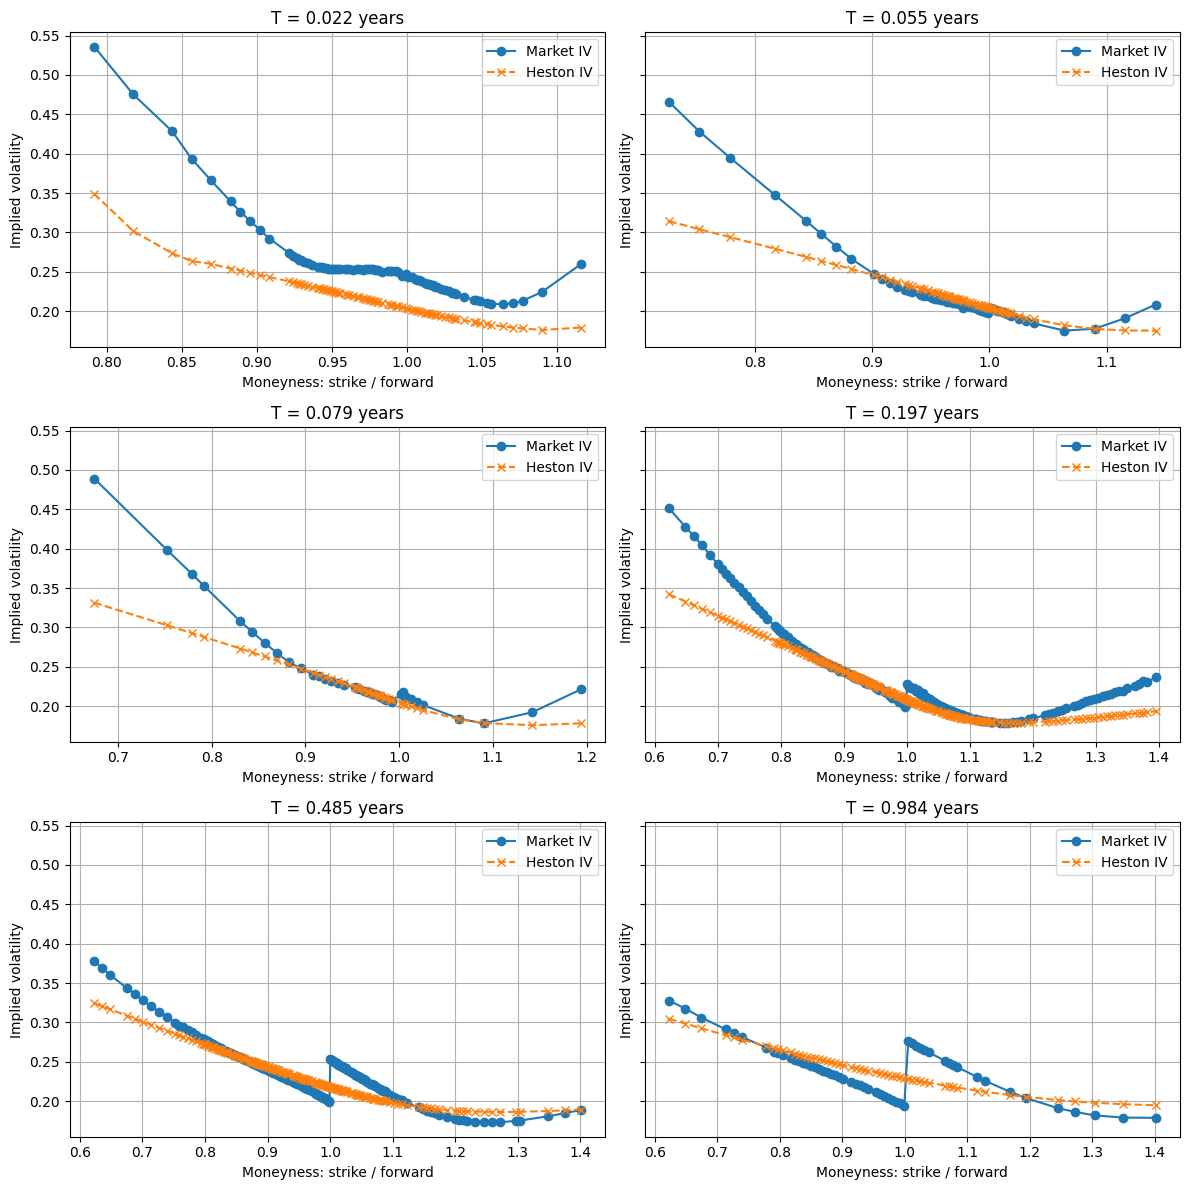

In [23]:
# ============================================================
# 20. One subplot per maturity smile
# ============================================================

n_smiles = len(selected_taus)
n_cols = 2
n_rows = int(np.ceil(n_smiles / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, 4 * n_rows), sharey=True)
axes = np.array(axes).reshape(-1)

for ax, tau_i in zip(axes, selected_taus):
    sub = smile_df[smile_df["tau_bucket"] == tau_i].sort_values("moneyness")
    if len(sub) < 3:
        ax.set_visible(False)
        continue
    ax.plot(sub["moneyness"], sub["market_iv_from_mid"], marker="o", linestyle="-", label="Market IV")
    ax.plot(sub["moneyness"], sub["heston_iv"], marker="x", linestyle="--", label="Heston IV")
    ax.set_title(f"T = {tau_i:.3f} years")
    ax.set_xlabel("Moneyness: strike / forward"); ax.set_ylabel("Implied volatility")
    ax.grid(True); ax.legend()

for j in range(len(selected_taus), len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

## Holdout evaluation

In [24]:
# ============================================================
# 21. Holdout evaluation
# ============================================================

test_base = test.copy()
test_base["moneyness"] = test_base["strike"] / test_base["forward"]

if CALIBRATION_MODE == "otm_only":
    test_eval = test_base[
        ((test_base["type"] == "put") & (test_base["strike"] < test_base["forward"]))
        | ((test_base["type"] == "call") & (test_base["strike"] >= test_base["forward"]))
    ].copy()

test_eval = test_eval[
    (test_eval["tau"] > MIN_TAU)
    & (test_eval["tau"] < MAX_TAU)
    & (test_eval["mid"] > MIN_MID_PRICE)
    & (test_eval["moneyness"] > MONEYNESS_LOW)
    & (test_eval["moneyness"] < MONEYNESS_HIGH)
].copy()

if len(test_eval) > 0:
    K_test = test_eval["strike"].to_numpy(float)
    tau_test = test_eval["tau"].to_numpy(float)
    r_test = test_eval["rate"].to_numpy(float)
    F_test = test_eval["forward"].to_numpy(float)
    type_test = test_eval["type"].to_numpy(str)

    test_eval["heston_price"] = heston_price_by_type(
        F=F_test, K=K_test, option_type=type_test,
        v0=v0, kappa=kappa, theta=theta, sigma=sigma, rho=rho, lambd=lambd,
        tau=tau_test, r=r_test,
    )

    test_eval["market_iv_from_mid"] = [
        implied_vol_black(price, fwd, strike, t, rate, opt_type)
        for price, fwd, strike, t, rate, opt_type in zip(
            test_eval["mid"], test_eval["forward"], test_eval["strike"],
            test_eval["tau"], test_eval["rate"], test_eval["type"])
    ]
    test_eval["heston_iv"] = [
        implied_vol_black(price, fwd, strike, t, rate, opt_type)
        for price, fwd, strike, t, rate, opt_type in zip(
            test_eval["heston_price"], test_eval["forward"], test_eval["strike"],
            test_eval["tau"], test_eval["rate"], test_eval["type"])
    ]

    test_eval["price_error"] = test_eval["heston_price"] - test_eval["mid"]
    test_eval["rel_price_error"] = test_eval["price_error"] / np.maximum(test_eval["mid"], 1e-8)
    test_eval["iv_error"] = test_eval["heston_iv"] - test_eval["market_iv_from_mid"]

    vtp = np.isfinite(test_eval["price_error"])
    vti = np.isfinite(test_eval["iv_error"])

    print("Holdout diagnostics")
    print("-------------------")
    print(f"Holdout options: {len(test_eval):,}")
    print(f"Price RMSE: {np.sqrt(np.mean(test_eval.loc[vtp, 'price_error'] ** 2)):.6f}")
    print(f"Price MAE:  {np.mean(np.abs(test_eval.loc[vtp, 'price_error'])):.6f}")
    print(f"Price MAPE: {np.mean(np.abs(test_eval.loc[vtp, 'rel_price_error'])):.4%}")
    print(f"IV RMSE in vol points: {100 * np.sqrt(np.mean(test_eval.loc[vti, 'iv_error'] ** 2)):.4f}")
    print(f"IV MAE in vol points:  {100 * np.mean(np.abs(test_eval.loc[vti, 'iv_error'])):.4f}")

    display(
        test_eval[["type", "strike", "tau", "moneyness", "mid", "heston_price",
                   "market_iv_from_mid", "heston_iv", "price_error", "iv_error"]]
        .sample(min(10, len(test_eval)), random_state=0)
    )
else:
    print("No holdout options remain after filtering.")

Holdout diagnostics
-------------------
Holdout options: 1,080
Price RMSE: 8.791331
Price MAE:  4.426471
Price MAPE: 18.1151%
IV RMSE in vol points: 2.9185
IV MAE in vol points:  1.5220


,type,strike,tau,moneyness,mid,heston_price,market_iv_from_mid,heston_iv,price_error,iv_error
4650,call,3915.0,0.484822,1.015989,229.800,197.243847,0.245482,0.214389,-32.556153,-0.031093
4791,call,4075.0,0.542356,1.057510,166.100,143.521397,0.229130,0.207949,-22.578603,-0.021181
3588,put,3025.0,0.293041,0.785023,14.350,12.280470,0.291342,0.281702,-2.069530,-0.009640
2786,put,3655.0,0.150685,0.948515,53.250,55.100569,0.222548,0.226405,1.850569,0.003857
3509,call,4265.0,0.235507,1.106818,23.750,23.034012,0.186227,0.184483,-0.715988,-0.001744
4923,call,5500.0,0.619068,1.427315,1.525,1.950932,0.184694,0.190263,0.425932,0.005569
5507,call,5000.0,0.983562,1.297559,25.600,35.626141,0.182705,0.198386,10.026141,0.015681
1308,call,3890.0,0.060274,1.009501,59.950,58.949000,0.203175,0.200479,-1.001000,-0.002696
2566,call,4400.0,0.120548,1.141852,1.750,1.384421,0.183152,0.177035,-0.365579,-0.006117
2445,put,3730.0,0.120548,0.967979,63.550,63.095425,0.219481,0.218526,-0.454575,-0.000955
